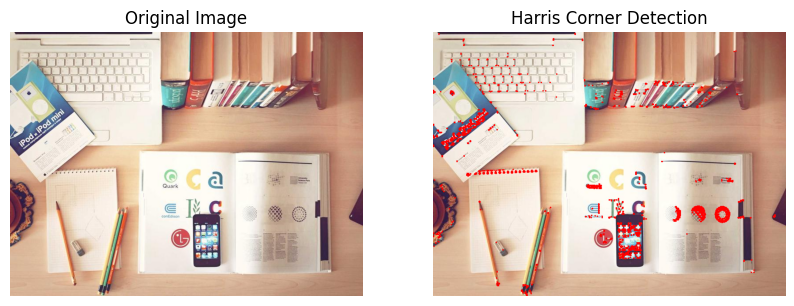

In [2]:
# Install libraries (only needed in Colab)
!pip install opencv-python matplotlib

import cv2
import numpy as np
from matplotlib import pyplot as plt
import urllib.request

# -------------------------------
# 1. Download sample image
# -------------------------------
image_url = "https://picsum.photos/seed/random3/800/600"
urllib.request.urlretrieve(image_url, "sample.jpg")

# -------------------------------
# 2. Read image
# -------------------------------
img = cv2.imread("sample.jpg")

if img is None:
    print("Error loading image")
    exit()

# Convert image to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Convert grayscale image to float32
gray = np.float32(gray)

# -------------------------------
# 3. Apply Harris Corner Detection
# -------------------------------
corners = cv2.cornerHarris(gray, 2, 3, 0.04)

# Dilate corner points for better visibility
corners = cv2.dilate(corners, None)

# Mark corners in red color
img[corners > 0.01 * corners.max()] = [0, 0, 255]

# Convert final image to RGB
result_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# -------------------------------
# 4. Display images
# -------------------------------
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Harris Corner Detection")
plt.imshow(result_rgb)
plt.axis('off')

plt.show()